# Anhedonic AI — 72B Orig Neuron & Activation Analysis

Mirrors `check_layers.ipynb` (7B) exactly, using only the orig dataset neurons.

**Paths:**
- Neurons  : `all_extraction/neurons/orig/`
- Activations: `all_extraction/activations/orig/`

**72B geometry:** 80 layers × 29,568 intermediate dim = 2,365,440 total MLP neurons


## Setup

In [2]:
import os, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 10

BASE         = "/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/72-Exp1/all_extraction"
NEURONS_DIR  = f"{BASE}/neurons/orig"
ACT_DIR      = f"{BASE}/activations/orig"

MONEY_FILE  = f"{NEURONS_DIR}/universal_money_neurons.csv"
REWARD_FILE = f"{NEURONS_DIR}/universal_reward_neurons.csv"
CORE_FILE   = f"{NEURONS_DIR}/master_incentive_core.csv"

NUM_LAYERS       = 80
INTERMEDIATE_DIM = 29568
TOTAL_NEURONS    = NUM_LAYERS * INTERMEDIATE_DIM  # 2,365,440
LAYERS           = list(range(NUM_LAYERS))

# Proportional region boundaries (scaled from 7B: early=0-8, mid=9-17, late=18-27)
EARLY_END = 26   # layers  0-26
MID_END   = 53   # layers 27-53
# Late      = layers 54-79

def layer_color(l):
    if l <= EARLY_END: return '#b0bec5'
    if l <= MID_END:   return '#ef5350'
    return '#0d47a1'

# Load neuron CSVs
df_money  = pd.read_csv(MONEY_FILE)
df_reward = pd.read_csv(REWARD_FILE)
df_core   = pd.read_csv(CORE_FILE)

money_idx  = set(zip(df_money['layer'],  df_money['neuron']))
reward_idx = set(zip(df_reward['layer'], df_reward['neuron']))
core_idx   = set(zip(df_core['layer'],   df_core['neuron']))

reward_only = reward_idx - money_idx
money_only  = money_idx  - reward_idx

print(f"72B orig neuron sets:")
print(f"  money_univ  : {len(money_idx):>7,}  ({len(money_idx)/TOTAL_NEURONS*100:.4f}%)")
print(f"  reward_univ : {len(reward_idx):>7,}  ({len(reward_idx)/TOTAL_NEURONS*100:.4f}%)")
print(f"  master_core : {len(core_idx):>7,}  ({len(core_idx)/TOTAL_NEURONS*100:.4f}%)")
print(f"  reward-only : {len(reward_only):>7,}")
print(f"  money-only  : {len(money_only):>7,}")
print(f"\nRegion boundaries: early=0-{EARLY_END}  mid={EARLY_END+1}-{MID_END}  late={MID_END+1}-79")


72B orig neuron sets:
  money_univ  :  23,707  (1.0022%)
  reward_univ :  21,893  (0.9255%)
  master_core :  11,736  (0.4961%)
  reward-only :  10,157
  money-only  :  11,971

Region boundaries: early=0-26  mid=27-53  late=54-79


## Load Activations & Compute Deltas

In [3]:
def load_mean(condition, domain):
    path = f"{ACT_DIR}/{condition}_activations_{domain}.pt"
    data = torch.load(path, map_location='cpu')
    tensors = [v for v in data.values() if isinstance(v, torch.Tensor)]
    stacked = torch.stack(tensors).float()  # [Q, 80, 29568]
    print(f"  {condition}_{domain}: {stacked.shape}")
    return stacked.mean(dim=0).numpy()      # [80, 29568]

print("Loading activations...")
m_neu = load_mean('neutral', 'math')
m_mon = load_mean('money',   'math')
m_rew = load_mean('reward',  'math')
g_neu = load_mean('neutral', 'geo')
g_mon = load_mean('money',   'geo')
g_rew = load_mean('reward',  'geo')

delta_mon_math = m_mon - m_neu
delta_mon_geo  = g_mon - g_neu
delta_rew_math = m_rew - m_neu
delta_rew_geo  = g_rew - g_neu

print(f"\nDelta magnitude check (mean |delta|):")
print(f"  money  / math: {np.abs(delta_mon_math).mean():.6f}")
print(f"  money  / geo:  {np.abs(delta_mon_geo).mean():.6f}")
print(f"  reward / math: {np.abs(delta_rew_math).mean():.6f}")
print(f"  reward / geo:  {np.abs(delta_rew_geo).mean():.6f}")


Loading activations...
  neutral_math: torch.Size([100, 80, 29568])
  money_math: torch.Size([100, 80, 29568])
  reward_math: torch.Size([100, 80, 29568])
  neutral_geo: torch.Size([100, 80, 29568])
  money_geo: torch.Size([100, 80, 29568])
  reward_geo: torch.Size([100, 80, 29568])

Delta magnitude check (mean |delta|):
  money  / math: 0.063835
  money  / geo:  0.066688
  reward / math: 0.055638
  reward / geo:  0.058766


## Fig 1 — Per-Layer Neuron Counts (all three sets)

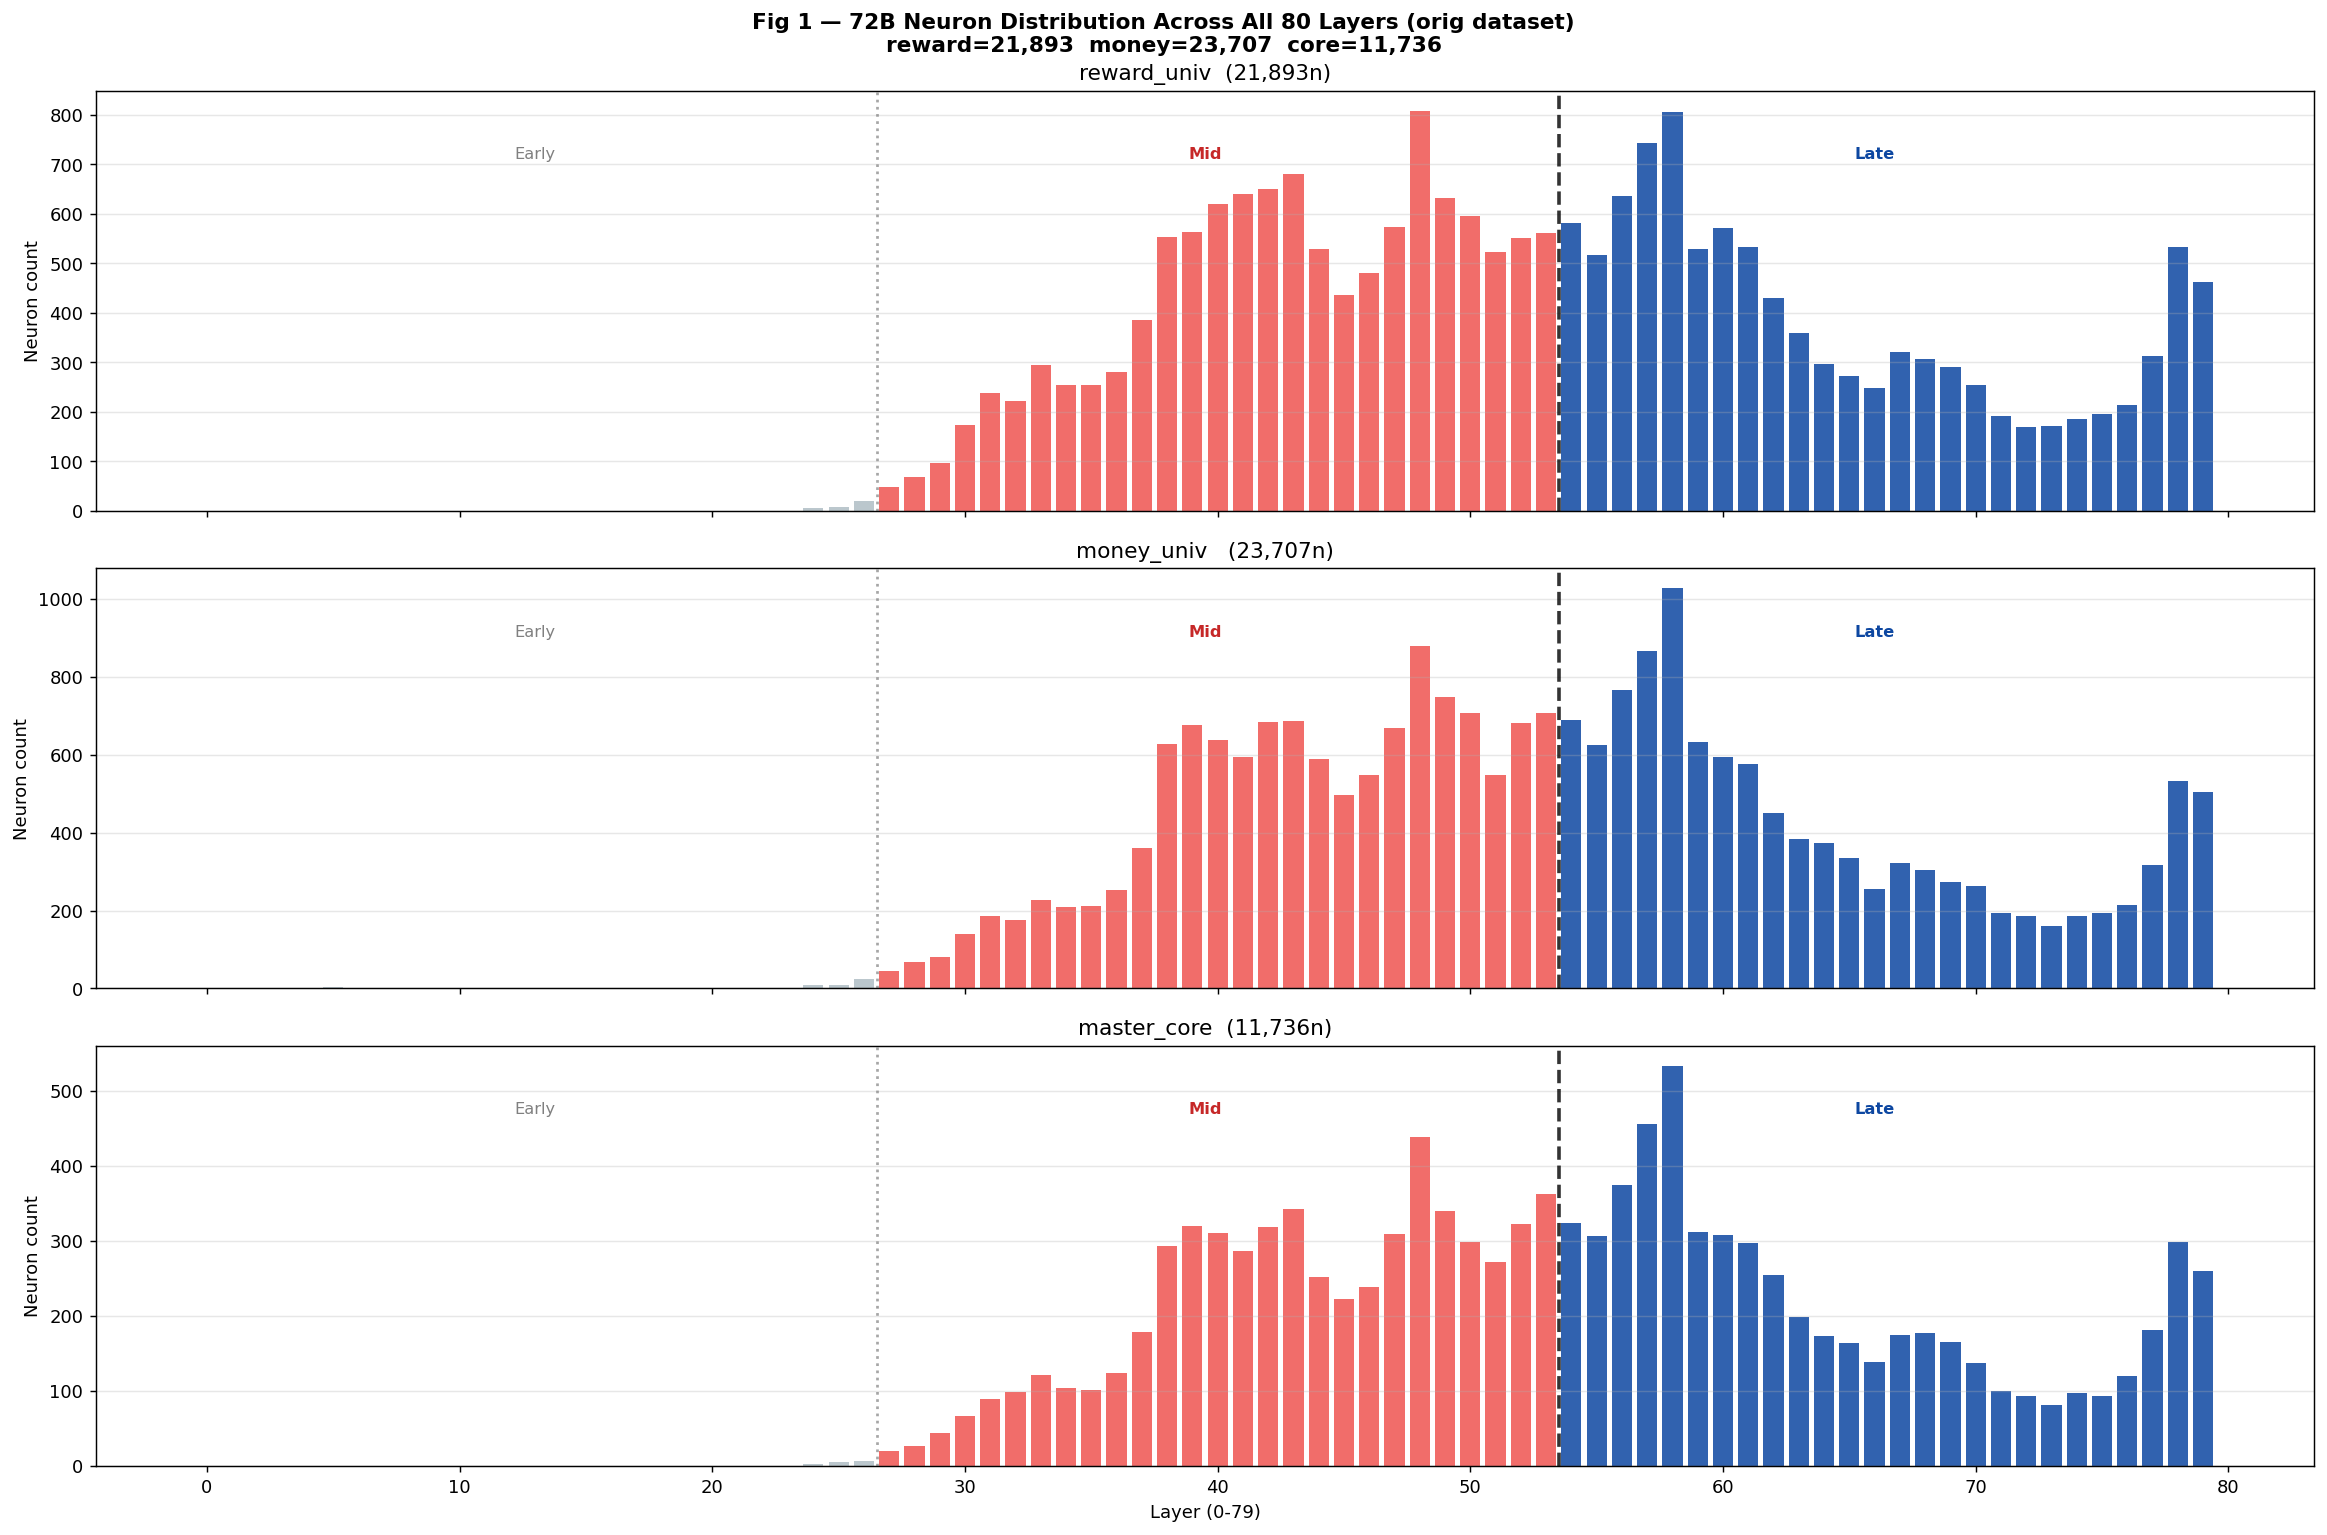

In [4]:
def counts_by_layer(neuron_set):
    c = np.zeros(NUM_LAYERS, dtype=int)
    for (l, _) in neuron_set:
        c[l] += 1
    return c

rew_by_layer  = counts_by_layer(reward_idx)
mon_by_layer  = counts_by_layer(money_idx)
core_by_layer = counts_by_layer(core_idx)

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle(
    'Fig 1 — 72B Neuron Distribution Across All 80 Layers (orig dataset)\n'
    f'reward={len(reward_idx):,}  money={len(money_idx):,}  core={len(core_idx):,}',
    fontweight='bold'
)

for ax, (counts, label, color) in zip(axes, [
    (rew_by_layer,  f'reward_univ  ({len(reward_idx):,}n)', '#ef5350'),
    (mon_by_layer,  f'money_univ   ({len(money_idx):,}n)',  '#42a5f5'),
    (core_by_layer, f'master_core  ({len(core_idx):,}n)',   '#ff7043'),
]):
    ax.bar(LAYERS, counts, color=[layer_color(l) for l in LAYERS], alpha=0.85)
    ax.axvline(EARLY_END + 0.5, color='gray',  ls=':',  lw=1.5, alpha=0.7)
    ax.axvline(MID_END   + 0.5, color='black', ls='--', lw=2.0, alpha=0.8)
    ax.set_ylabel('Neuron count')
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='y')
    ymax = counts.max() if counts.max() > 0 else 1
    ax.text(EARLY_END/2,              ymax*0.88, 'Early', ha='center', fontsize=9, color='gray')
    ax.text((EARLY_END+MID_END)/2,    ymax*0.88, 'Mid',   ha='center', fontsize=9, color='#c62828', fontweight='bold')
    ax.text((MID_END+79)/2,           ymax*0.88, 'Late',  ha='center', fontsize=9, color='#0d47a1', fontweight='bold')

axes[-1].set_xlabel('Layer (0-79)')
plt.tight_layout()
plt.savefig(f'{BASE}/72b_orig_fig1_per_layer_counts.png', bbox_inches='tight', dpi=150)
plt.show()


## Fig 2 — Exclusive Neuron Distribution (signal vs canceller)

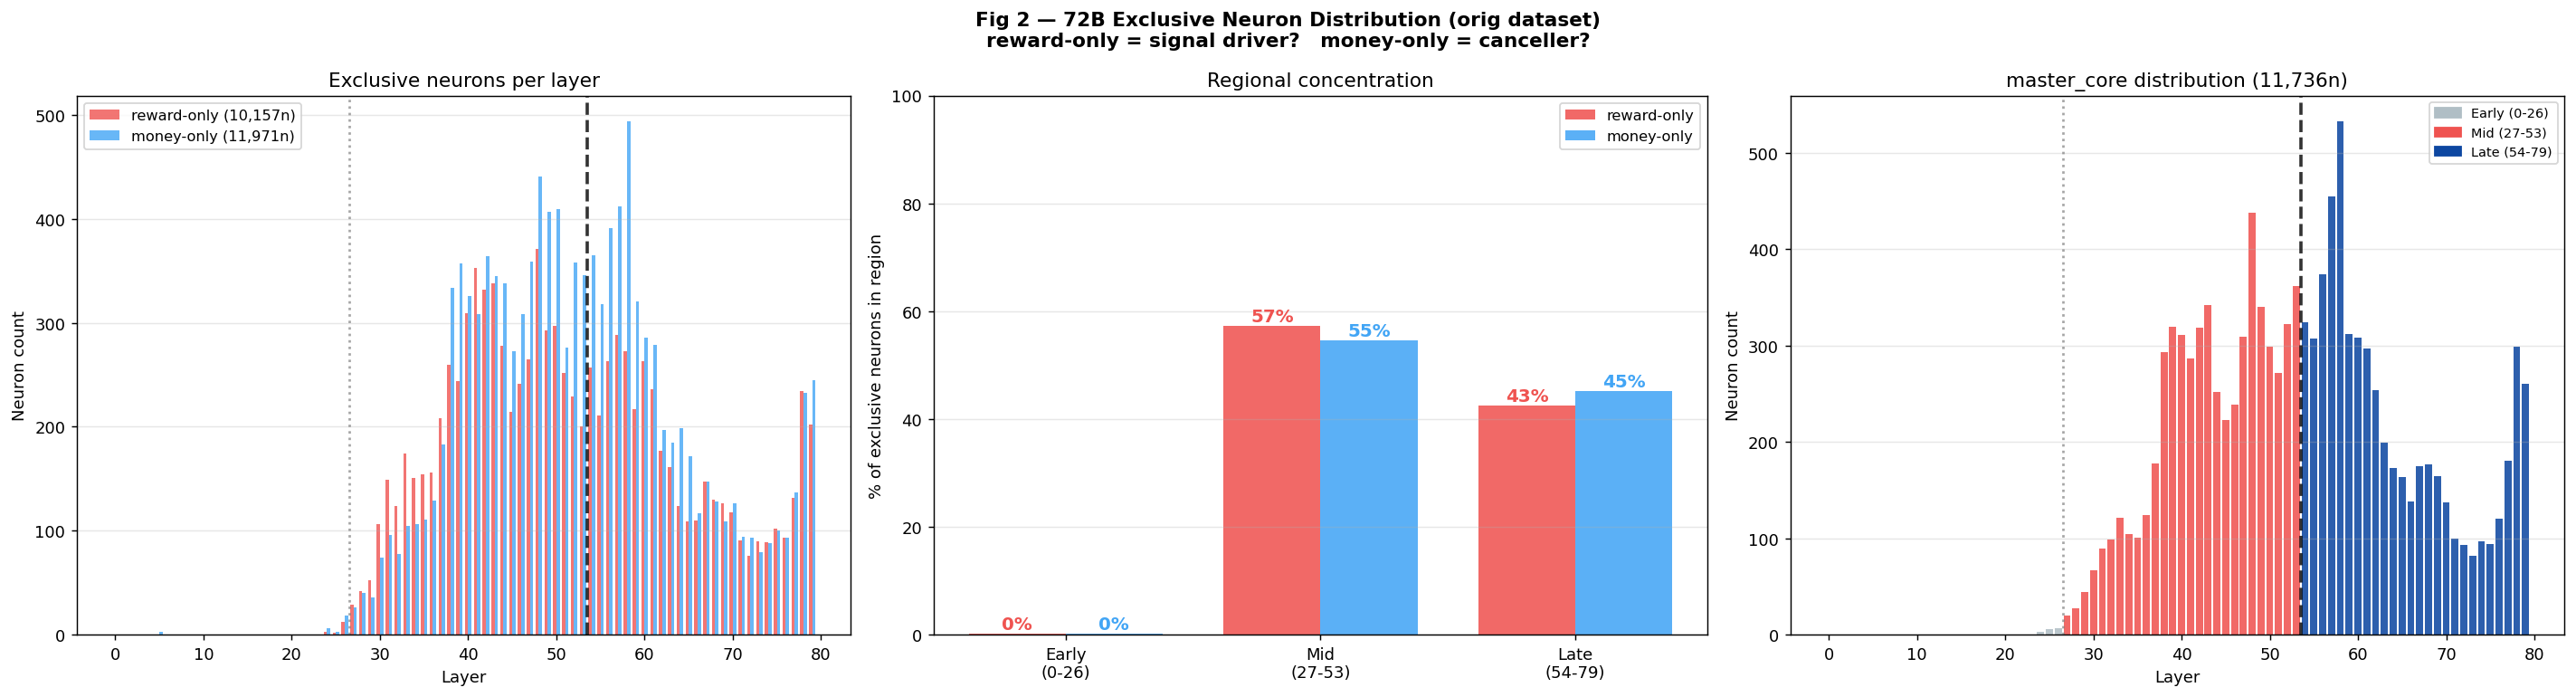

Regional % — reward-only: Early=0%  Mid=57%  Late=43%
Regional % — money-only:  Early=0%  Mid=55%  Late=45%

7B reference:
  reward-only: Late~70%  → signal driver in late layers
  money-only:  Mid ~60%  → canceller in mid layers


In [5]:
rew_only_by_layer = counts_by_layer(reward_only)
mon_only_by_layer = counts_by_layer(money_only)

def region_pct(counts):
    total = counts.sum()
    if total == 0: return [0.0, 0.0, 0.0]
    return [
        counts[:EARLY_END+1].sum()         / total * 100,
        counts[EARLY_END+1:MID_END+1].sum()/ total * 100,
        counts[MID_END+1:].sum()           / total * 100,
    ]

r_pct = region_pct(rew_only_by_layer)
m_pct = region_pct(mon_only_by_layer)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    'Fig 2 — 72B Exclusive Neuron Distribution (orig dataset)\n'
    'reward-only = signal driver?   money-only = canceller?',
    fontweight='bold'
)

w = 0.38
region_labels = [f'Early\n(0-{EARLY_END})', f'Mid\n({EARLY_END+1}-{MID_END})', f'Late\n({MID_END+1}-79)']
x = np.arange(3)

# Panel 1: per-layer side-by-side
ax = axes[0]
ax.bar([l-w/2 for l in LAYERS], rew_only_by_layer, width=w, color='#ef5350', alpha=0.8, label=f'reward-only ({len(reward_only):,}n)')
ax.bar([l+w/2 for l in LAYERS], mon_only_by_layer, width=w, color='#42a5f5', alpha=0.8, label=f'money-only ({len(money_only):,}n)')
ax.axvline(EARLY_END+0.5, color='gray',  ls=':',  lw=1.5, alpha=0.7)
ax.axvline(MID_END+0.5,   color='black', ls='--', lw=2.0, alpha=0.8)
ax.set_xlabel('Layer'); ax.set_ylabel('Neuron count')
ax.set_title('Exclusive neurons per layer')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Panel 2: regional % breakdown
ax2 = axes[1]
ax2.bar(x-w/2, r_pct, width=w, color='#ef5350', alpha=0.87, label='reward-only')
ax2.bar(x+w/2, m_pct, width=w, color='#42a5f5', alpha=0.87, label='money-only')
for i, (r, m) in enumerate(zip(r_pct, m_pct)):
    ax2.text(i-w/2, r+0.8, f'{r:.0f}%', ha='center', fontsize=11, fontweight='bold', color='#ef5350')
    ax2.text(i+w/2, m+0.8, f'{m:.0f}%', ha='center', fontsize=11, fontweight='bold', color='#42a5f5')
ax2.set_xticks(x); ax2.set_xticklabels(region_labels, fontsize=10)
ax2.set_ylabel('% of exclusive neurons in region')
ax2.set_title('Regional concentration')
ax2.legend(fontsize=9); ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: master_core distribution
ax3 = axes[2]
ax3.bar(LAYERS, core_by_layer, color=[layer_color(l) for l in LAYERS], alpha=0.87)
ax3.axvline(EARLY_END+0.5, color='gray',  ls=':',  lw=1.5, alpha=0.7)
ax3.axvline(MID_END+0.5,   color='black', ls='--', lw=2.0, alpha=0.8)
ax3.set_xlabel('Layer'); ax3.set_ylabel('Neuron count')
ax3.set_title(f'master_core distribution ({len(core_idx):,}n)')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(handles=[
    mpatches.Patch(color='#b0bec5', label=f'Early (0-{EARLY_END})'),
    mpatches.Patch(color='#ef5350', label=f'Mid ({EARLY_END+1}-{MID_END})'),
    mpatches.Patch(color='#0d47a1', label=f'Late ({MID_END+1}-79)'),
], fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/72b_orig_fig2_exclusive_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Regional % — reward-only: Early={r_pct[0]:.0f}%  Mid={r_pct[1]:.0f}%  Late={r_pct[2]:.0f}%")
print(f"Regional % — money-only:  Early={m_pct[0]:.0f}%  Mid={m_pct[1]:.0f}%  Late={m_pct[2]:.0f}%")
print()
print(f"7B reference:")
print(f"  reward-only: Late~70%  → signal driver in late layers")
print(f"  money-only:  Mid ~60%  → canceller in mid layers")


## Fig 3 — Mean |Delta| Per Layer (activation signal strength)

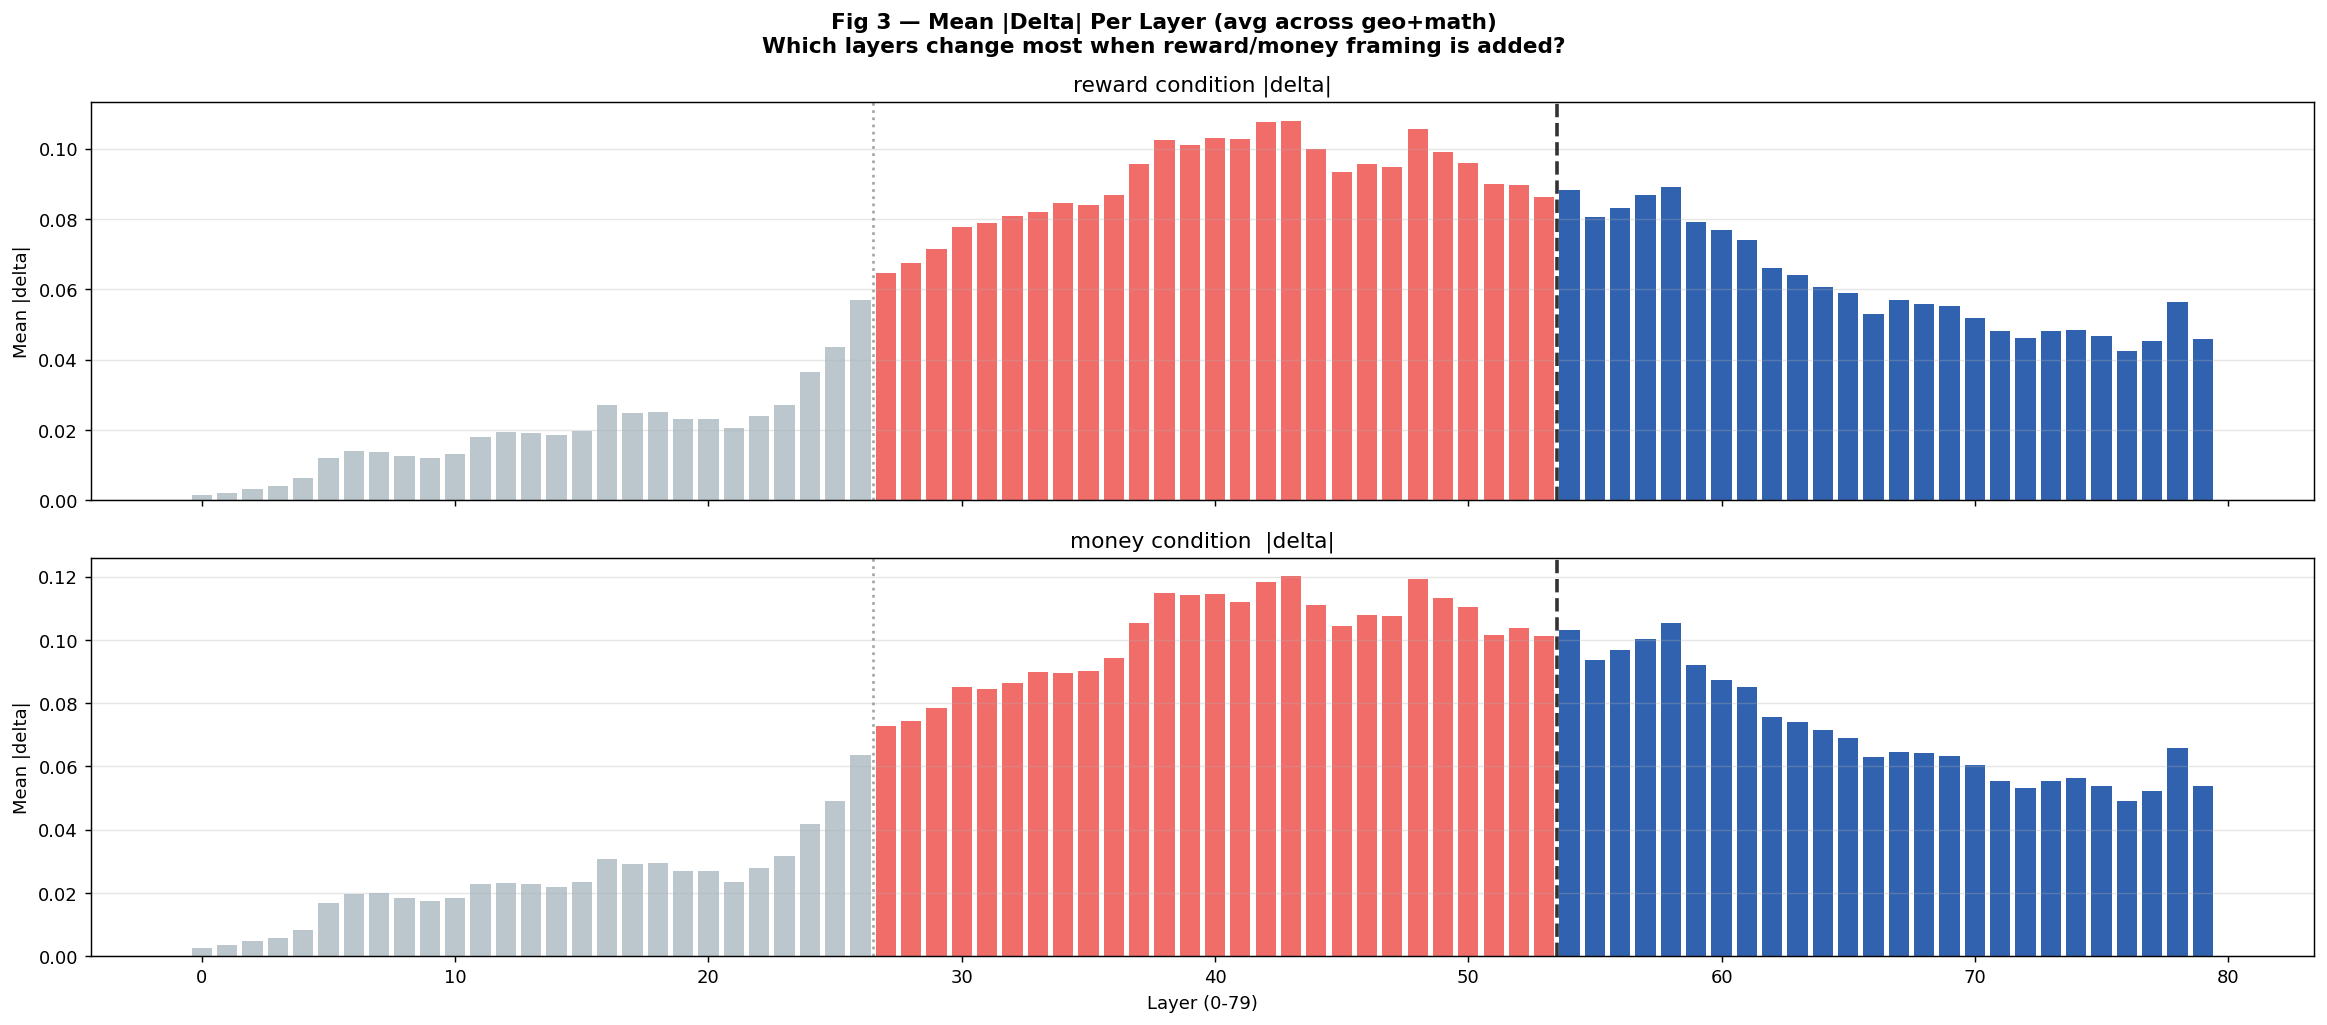

Top 10 layers by reward |delta|: [43, 42, 48, 40, 41, 38, 39, 44, 49, 50]
Top 10 layers by money  |delta|: [43, 48, 42, 38, 40, 39, 49, 41, 44, 50]


In [6]:
# How strongly does each layer respond to incentive framing?
mon_delta_per_layer = (np.abs(delta_mon_math) + np.abs(delta_mon_geo)) / 2   # [80, 29568]
rew_delta_per_layer = (np.abs(delta_rew_math) + np.abs(delta_rew_geo)) / 2

mon_mean_per_layer = mon_delta_per_layer.mean(axis=1)  # [80]
rew_mean_per_layer = rew_delta_per_layer.mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.suptitle(
    'Fig 3 — Mean |Delta| Per Layer (avg across geo+math)\n'
    'Which layers change most when reward/money framing is added?',
    fontweight='bold'
)

for ax, (vals, label, color) in zip(axes, [
    (rew_mean_per_layer, 'reward condition |delta|', '#ef5350'),
    (mon_mean_per_layer, 'money condition  |delta|', '#42a5f5'),
]):
    ax.bar(LAYERS, vals, color=[layer_color(l) for l in LAYERS], alpha=0.85)
    ax.axvline(EARLY_END+0.5, color='gray',  ls=':',  lw=1.5, alpha=0.7)
    ax.axvline(MID_END+0.5,   color='black', ls='--', lw=2.0, alpha=0.8)
    ax.set_ylabel('Mean |delta|')
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Layer (0-79)')
plt.tight_layout()
plt.savefig(f'{BASE}/72b_orig_fig3_delta_per_layer.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 10 layers by reward |delta|:", np.argsort(rew_mean_per_layer)[::-1][:10].tolist())
print("Top 10 layers by money  |delta|:", np.argsort(mon_mean_per_layer)[::-1][:10].tolist())


## Fig 4 — Top Layers in master_core (ablation candidates)

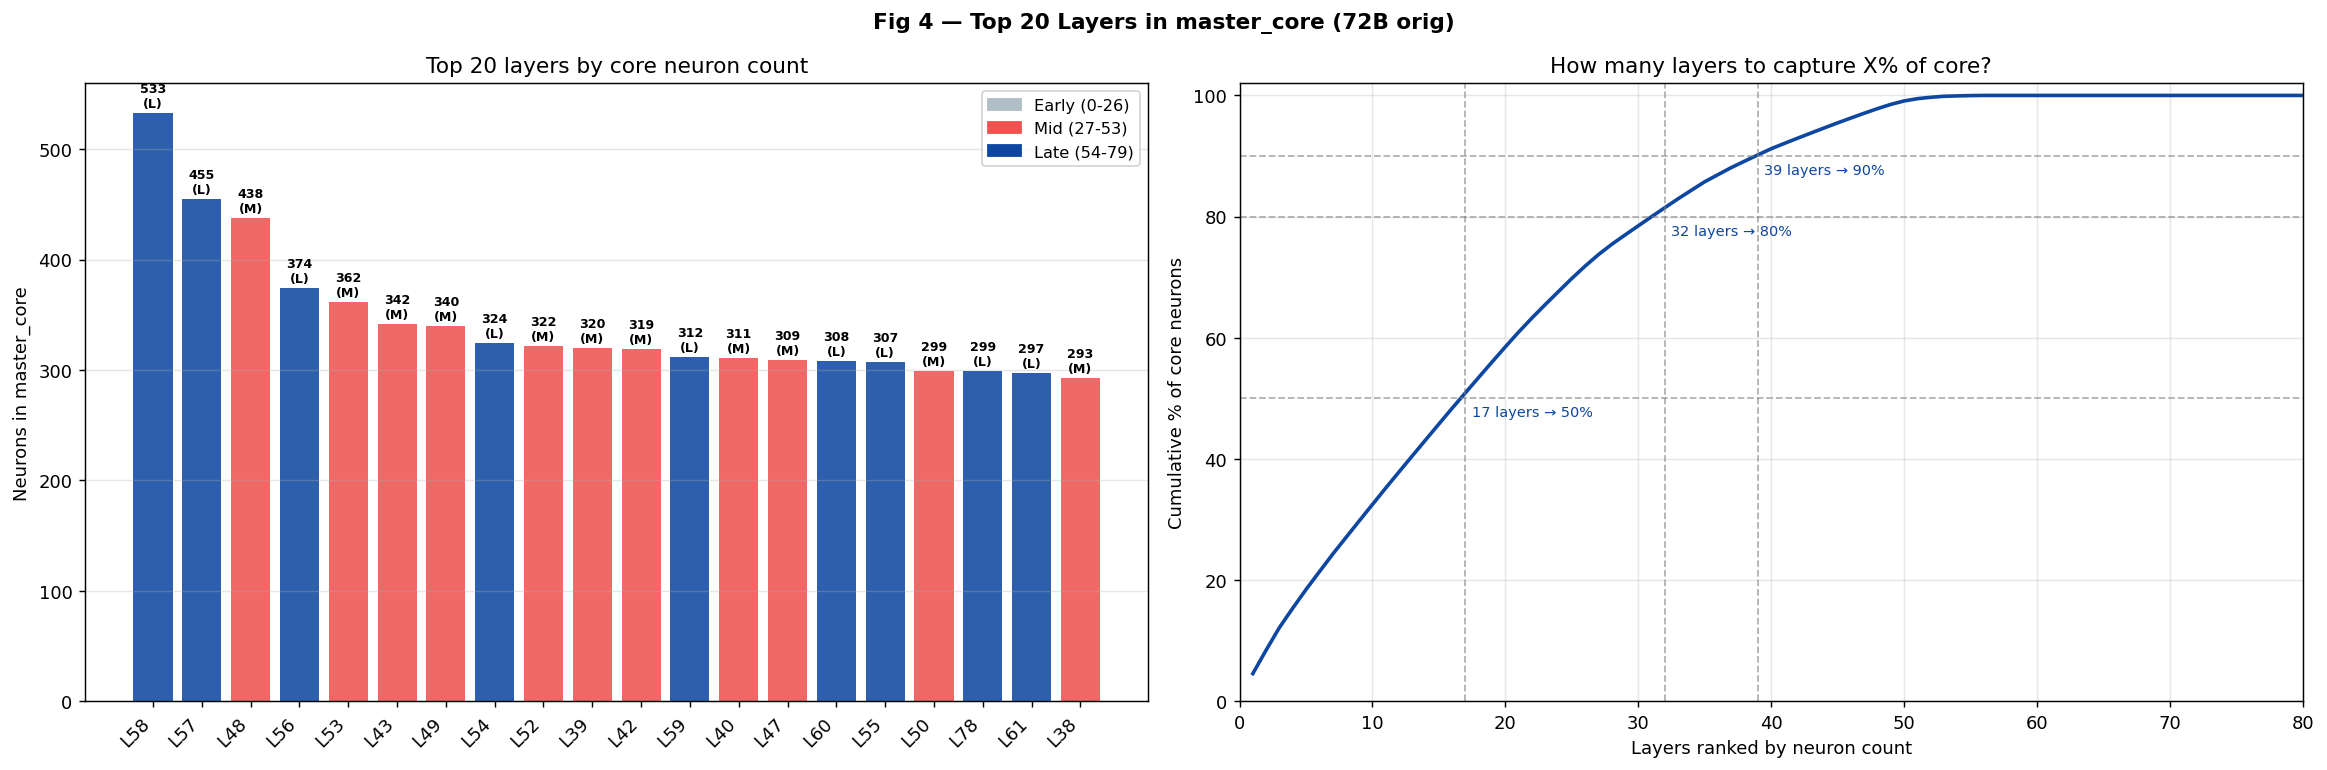

Top 20 ablation candidate layers:
  Rank   Layer    Count  Region   % of core
  ------------------------------------------
     1      58      533    Late       4.54%
     2      57      455    Late       3.88%
     3      48      438     Mid       3.73%
     4      56      374    Late       3.19%
     5      53      362     Mid       3.08%
     6      43      342     Mid       2.91%
     7      49      340     Mid       2.90%
     8      54      324    Late       2.76%
     9      52      322     Mid       2.74%
    10      39      320     Mid       2.73%
    11      42      319     Mid       2.72%
    12      59      312    Late       2.66%
    13      40      311     Mid       2.65%
    14      47      309     Mid       2.63%
    15      60      308    Late       2.62%
    16      55      307    Late       2.62%
    17      50      299     Mid       2.55%
    18      78      299    Late       2.55%
    19      61      297    Late       2.53%
    20      38      293     Mid       2.5

In [7]:
top_n = 20
sorted_layers = np.argsort(core_by_layer)[::-1][:top_n]
sorted_counts = core_by_layer[sorted_layers]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Fig 4 — Top {top_n} Layers in master_core (72B orig)', fontweight='bold')

# Panel 1: ranked bar
ax = axes[0]
ax.bar(range(top_n), sorted_counts,
       color=[layer_color(l) for l in sorted_layers], alpha=0.87)
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'L{l}' for l in sorted_layers], rotation=45, ha='right')
ax.set_ylabel('Neurons in master_core')
ax.set_title(f'Top {top_n} layers by core neuron count')
ax.grid(True, alpha=0.3, axis='y')
for i, (l, c) in enumerate(zip(sorted_layers, sorted_counts)):
    region = 'E' if l<=EARLY_END else ('M' if l<=MID_END else 'L')
    ax.text(i, c + sorted_counts.max()*0.01, f'{c}\n({region})',
            ha='center', fontsize=7, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#b0bec5', label=f'Early (0-{EARLY_END})'),
    mpatches.Patch(color='#ef5350', label=f'Mid ({EARLY_END+1}-{MID_END})'),
    mpatches.Patch(color='#0d47a1', label=f'Late ({MID_END+1}-79)'),
], fontsize=9)

# Panel 2: cumulative coverage
ax2 = axes[1]
all_sorted  = np.argsort(core_by_layer)[::-1]
cumulative  = np.cumsum(core_by_layer[all_sorted]) / len(core_idx) * 100
ax2.plot(range(1, NUM_LAYERS+1), cumulative, color='#0d47a1', lw=2)
for pct_target in [50, 80, 90]:
    n_layers = int(np.searchsorted(cumulative, pct_target)) + 1
    ax2.axhline(pct_target, color='gray', ls='--', lw=1, alpha=0.6)
    ax2.axvline(n_layers,   color='gray', ls='--', lw=1, alpha=0.6)
    ax2.text(n_layers+0.5, pct_target-3, f'{n_layers} layers → {pct_target}%',
             fontsize=8, color='#0d47a1')
ax2.set_xlabel('Layers ranked by neuron count')
ax2.set_ylabel('Cumulative % of core neurons')
ax2.set_title('How many layers to capture X% of core?')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, NUM_LAYERS); ax2.set_ylim(0, 102)

plt.tight_layout()
plt.savefig(f'{BASE}/72b_orig_fig4_top_layers.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Top 20 ablation candidate layers:")
print(f"  {'Rank':>4}  {'Layer':>6}  {'Count':>7}  {'Region':>6}  {'% of core':>10}")
print(f"  {'-'*42}")
for rank, (l, c) in enumerate(zip(sorted_layers, sorted_counts), 1):
    region = 'Early' if l<=EARLY_END else ('Mid' if l<=MID_END else 'Late')
    print(f"  {rank:>4}  {l:>6}  {c:>7}  {region:>6}  {c/len(core_idx)*100:>9.2f}%")


## Fig 5 — Neuron Density Heatmap (layer × neuron-index)

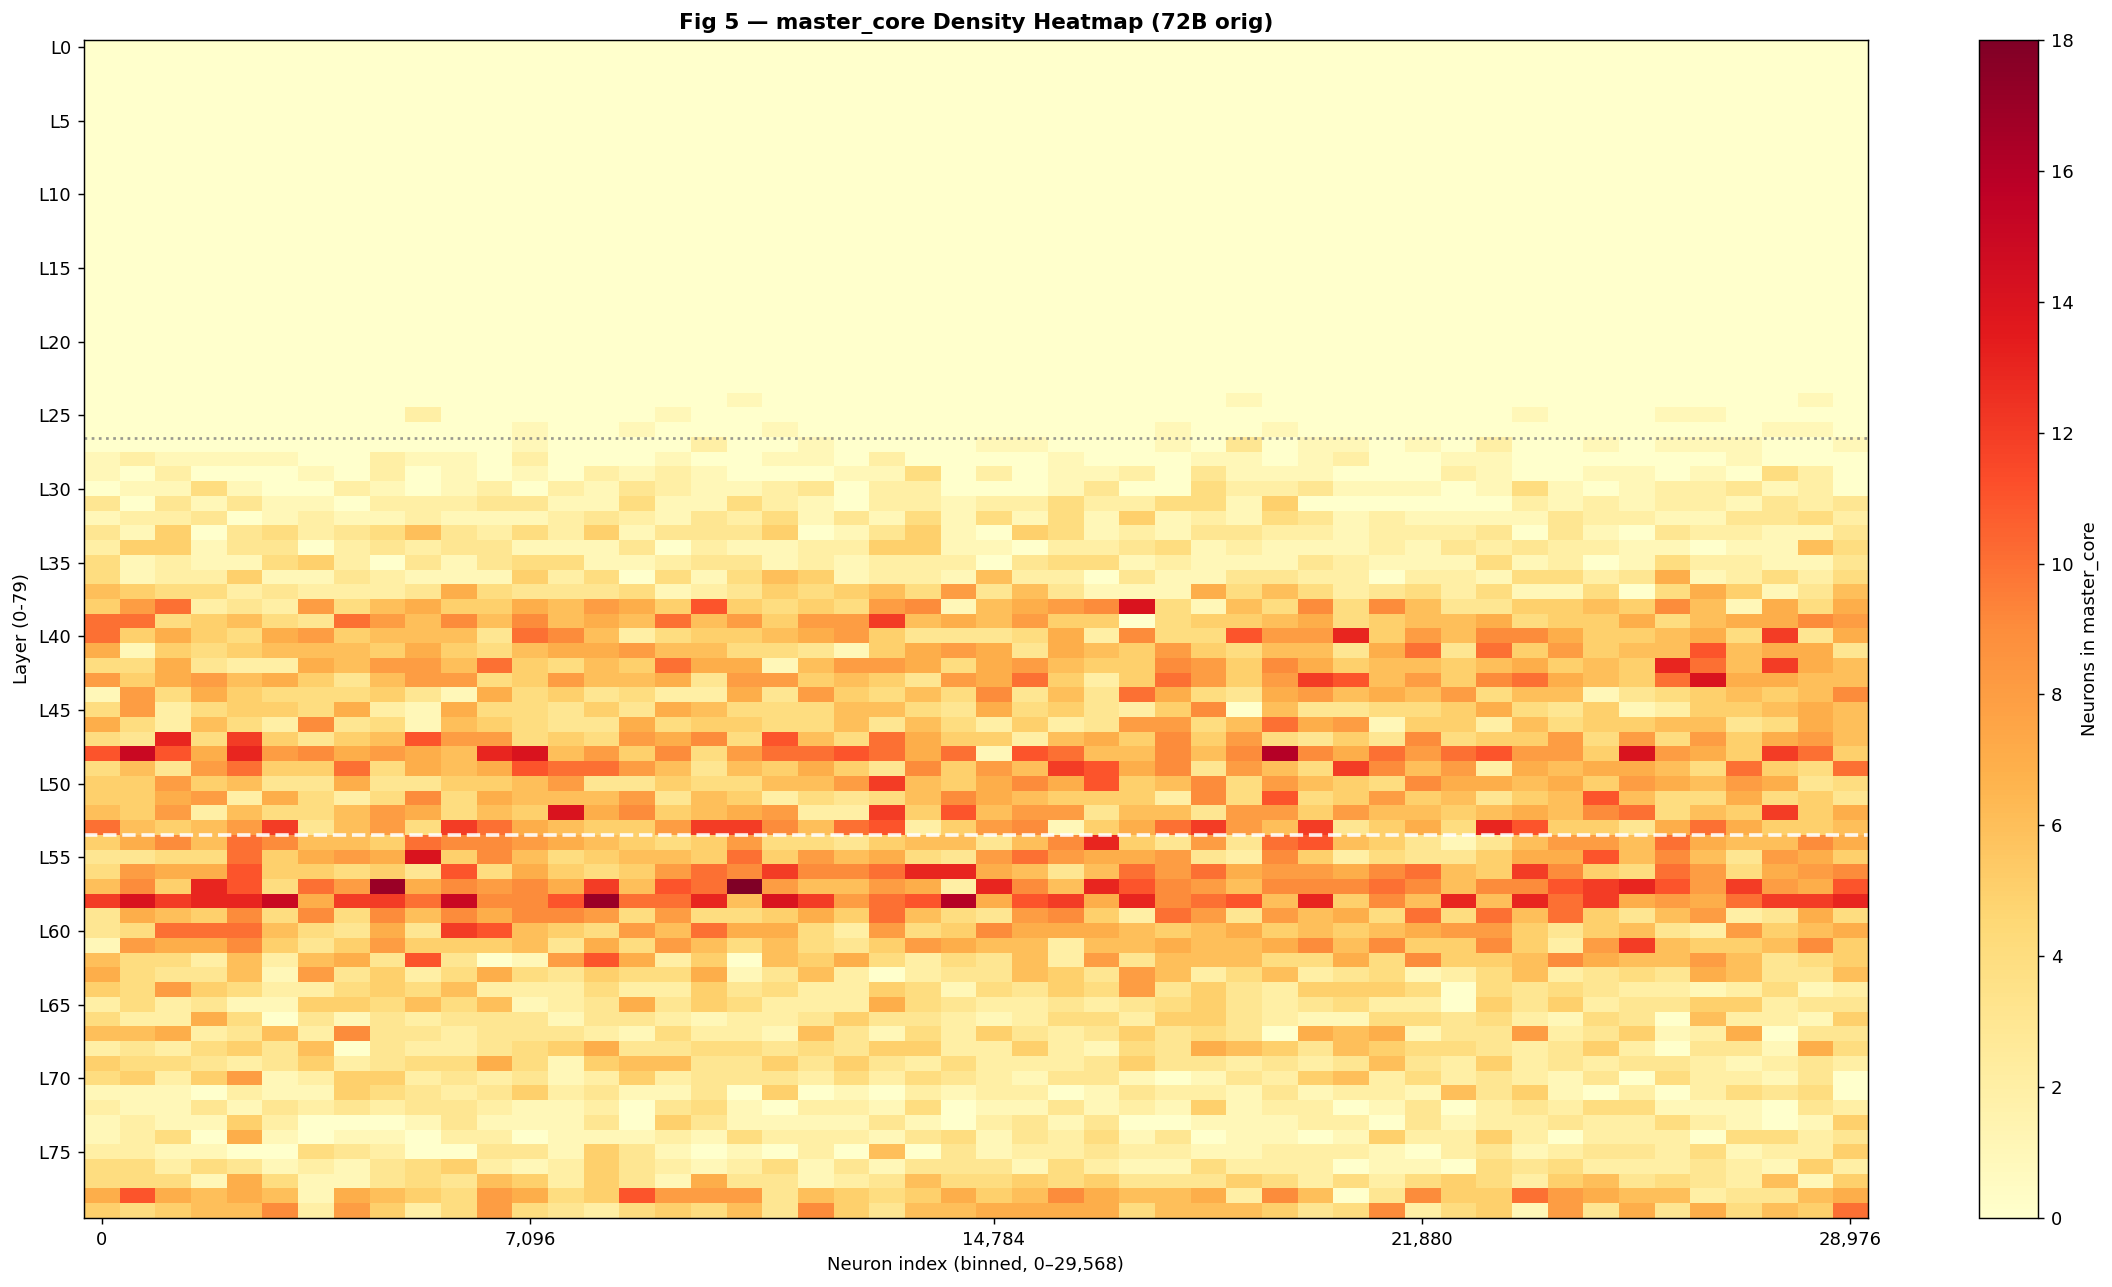

In [8]:
N_BINS = 50
heatmap = np.zeros((NUM_LAYERS, N_BINS), dtype=int)
for (l, n) in core_idx:
    b = min(int(n / INTERMEDIATE_DIM * N_BINS), N_BINS-1)
    heatmap[l, b] += 1

fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(heatmap, aspect='auto', cmap='YlOrRd', origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Neurons in master_core')
ax.axhline(EARLY_END+0.5, color='gray',  ls=':',  lw=1.5, alpha=0.8)
ax.axhline(MID_END+0.5,   color='white', ls='--', lw=2.0, alpha=0.9)
ax.set_xlabel('Neuron index (binned, 0–29,568)')
ax.set_ylabel('Layer (0-79)')
ax.set_title('Fig 5 — master_core Density Heatmap (72B orig)', fontweight='bold')

ytick_pos = list(range(0, NUM_LAYERS, 5))
ax.set_yticks(ytick_pos)
ax.set_yticklabels([f'L{l}' for l in ytick_pos])

bin_edges = np.linspace(0, INTERMEDIATE_DIM, N_BINS+1)
xtick_pos = [0, N_BINS//4, N_BINS//2, 3*N_BINS//4, N_BINS-1]
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f'{int(bin_edges[p]):,}' for p in xtick_pos])

plt.tight_layout()
plt.savefig(f'{BASE}/72b_orig_fig5_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## Summary

In [9]:
print("=" * 65)
print("72B ORIG NEURON ANALYSIS — SUMMARY")
print("=" * 65)

for name, nset in [('reward_univ', reward_idx), ('money_univ', money_idx),
                   ('master_core', core_idx),   ('reward-only', reward_only),
                   ('money-only',  money_only)]:
    c = counts_by_layer(nset)
    early = c[:EARLY_END+1].sum()
    mid   = c[EARLY_END+1:MID_END+1].sum()
    late  = c[MID_END+1:].sum()
    total = len(nset)
    if total == 0: continue
    print(f"\n  {name} ({total:,} neurons):")
    print(f"    Early (0-{EARLY_END}):  {early:>6,}  ({early/total*100:>5.1f}%)")
    print(f"    Mid   ({EARLY_END+1}-{MID_END}):  {mid:>6,}  ({mid/total*100:>5.1f}%)")
    print(f"    Late  ({MID_END+1}-79): {late:>6,}  ({late/total*100:>5.1f}%)")

print(f"\n{'=' * 65}")
print("TOP 10 ABLATION CANDIDATE LAYERS (master_core):")
top10 = np.argsort(core_by_layer)[::-1][:10]
for rank, l in enumerate(top10, 1):
    region = 'Early' if l<=EARLY_END else ('Mid' if l<=MID_END else 'Late')
    print(f"  {rank:>2}. Layer {l:>3}  ({region}): {core_by_layer[l]:>5} neurons")


72B ORIG NEURON ANALYSIS — SUMMARY

  reward_univ (21,893 neurons):
    Early (0-26):      33  (  0.2%)
    Mid   (27-53):  11,723  ( 53.5%)
    Late  (54-79): 10,137  ( 46.3%)

  money_univ (23,707 neurons):
    Early (0-26):      46  (  0.2%)
    Mid   (27-53):  12,435  ( 52.5%)
    Late  (54-79): 11,226  ( 47.4%)

  master_core (11,736 neurons):
    Early (0-26):      16  (  0.1%)
    Mid   (27-53):   5,902  ( 50.3%)
    Late  (54-79):  5,818  ( 49.6%)

  reward-only (10,157 neurons):
    Early (0-26):      17  (  0.2%)
    Mid   (27-53):   5,821  ( 57.3%)
    Late  (54-79):  4,319  ( 42.5%)

  money-only (11,971 neurons):
    Early (0-26):      30  (  0.3%)
    Mid   (27-53):   6,533  ( 54.6%)
    Late  (54-79):  5,408  ( 45.2%)

TOP 10 ABLATION CANDIDATE LAYERS (master_core):
   1. Layer  58  (Late):   533 neurons
   2. Layer  57  (Late):   455 neurons
   3. Layer  48  (Mid):   438 neurons
   4. Layer  56  (Late):   374 neurons
   5. Layer  53  (Mid):   362 neurons
   6. Layer  43